In [8]:
import pandas as pd
import matplotlib as plt
import numpy as np

In [2]:
rs50_data = pd.read_csv("Reliance_RS50.csv", skiprows=1)
rs50_data_ocv = pd.read_csv("Reliance_RS50_OCV.csv", skiprows=1)

In [3]:
rs50_data_ocv

,Time [s],Voltage [V],SOC [%],Power [W],Current [A],Charge [Ah],OCV [V],Temperature [°C],Heat Generation [W],Cooling Power [W],Resistive Heat [W],Reversible Heat [W],Hysteresis Heat [W]
0,0.0,4.149204,100.000000,-20.746020,-5,0.000000,4.182127,25.000000,-0.073669,0.000000,0.164617,-0.317462,0.079176
1,0.1,4.148540,99.997222,-20.742701,-5,-0.000139,4.182003,24.999881,-0.070776,0.000032,0.167315,-0.317416,0.079326
2,0.2,4.147889,99.994444,-20.739446,-5,-0.000278,4.181879,24.999766,-0.067946,0.000063,0.169949,-0.317371,0.079476
3,0.3,4.147250,99.991667,-20.736251,-5,-0.000417,4.181755,24.999657,-0.065177,0.000093,0.172523,-0.317325,0.079625
4,0.4,4.146623,99.988889,-20.733117,-5,-0.000556,4.181631,24.999551,-0.062469,0.000122,0.175036,-0.317279,0.079775
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36928,3692.8,2.500651,-2.577778,-12.503256,-5,-5.128889,2.691063,31.004861,1.840559,-1.630691,0.952058,0.218549,0.669952
36929,3692.9,2.500476,-2.580556,-12.502379,-5,-5.129028,2.690905,31.005208,1.840807,-1.630785,0.952148,0.218649,0.670009
36930,3693.0,2.500300,-2.583333,-12.501502,-5,-5.129167,2.690748,31.005555,1.841054,-1.630879,0.952238,0.218750,0.670066
36931,3693.1,2.500125,-2.586111,-12.500624,-5,-5.129306,2.690591,31.005902,1.841301,-1.630974,0.952328,0.218850,0.670123


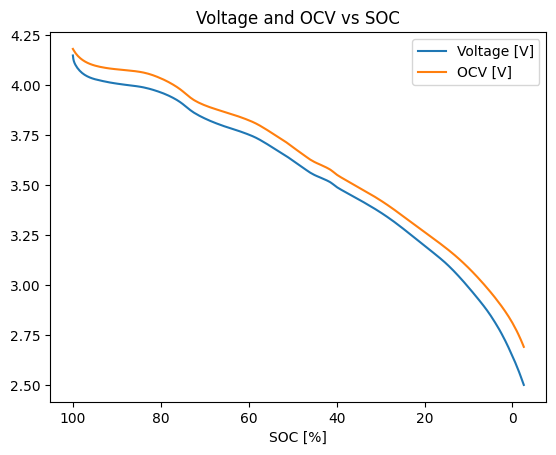

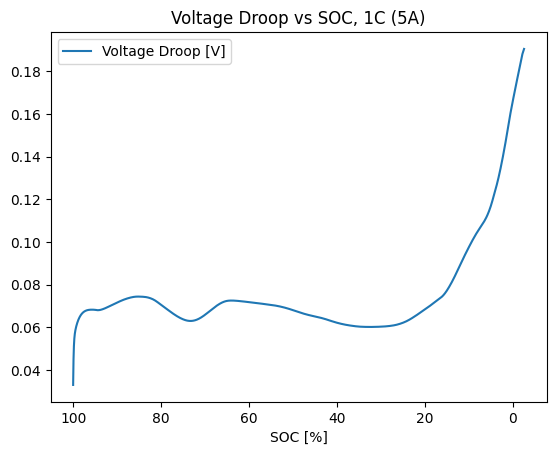

In [4]:
ax = rs50_data_ocv.plot(x="SOC [%]", y = "Voltage [V]")
ax = rs50_data_ocv.plot(x="SOC [%]", y = "OCV [V]", ax=ax)
ax.set_title("Voltage and OCV vs SOC")
ax.invert_xaxis()


rs50_data_ocv["Voltage Droop [V]"] = rs50_data_ocv["OCV [V]"] - rs50_data_ocv["Voltage [V]"]
ax = rs50_data_ocv.plot(x="SOC [%]", y = "Voltage Droop [V]")
ax.set_title("Voltage Droop vs SOC, 1C (5A)")
ax.invert_xaxis()



Text(0.5, 1.0, 'Voltage (V) vs. Disharged Capacity (Ah)')

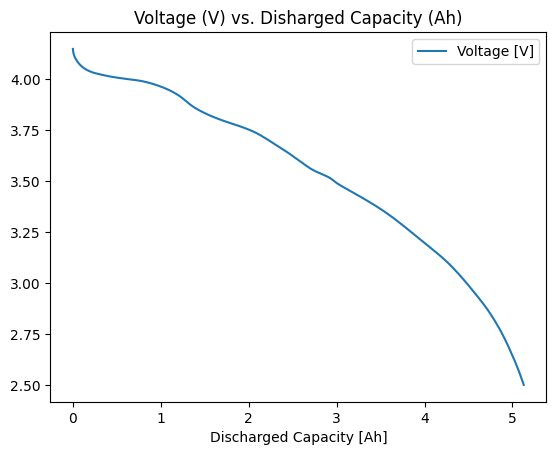

In [5]:
rs50_data["Discharged Capacity [Ah]"] = -1 * rs50_data["Charge [Ah]"]
ax = rs50_data.plot(x="Discharged Capacity [Ah]", y = "Voltage [V]")
ax.set_title("Voltage (V) vs. Disharged Capacity (Ah)")


,SOC [%],OCV [V]
0,100.000000,4.182127
1,98.989899,4.149690
2,97.979798,4.129412
3,96.969697,4.115520
4,95.959596,4.105659


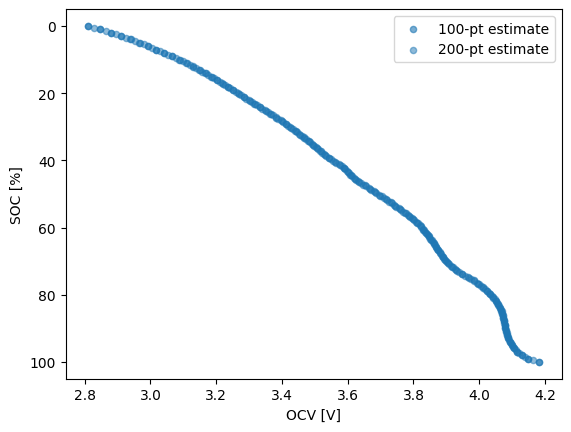

In [15]:
source_curve = (
    rs50_data_ocv[["SOC [%]", "OCV [V]"]]
    .dropna()
    .query("`SOC [%]` >= 0 and `SOC [%]` <= 100")
    .drop_duplicates(subset="SOC [%]", keep="first")
    .sort_values("SOC [%]")
)

soc_bp = source_curve["SOC [%]"].to_numpy(dtype=float)
ocv_bp = source_curve["OCV [V]"].to_numpy(dtype=float)

# Build both lookup tables from 100% down to 0%.
estimate_100_pts = pd.DataFrame({
    "SOC [%]": np.linspace(100.0, 0.0, 100)
})
estimate_100_pts["OCV [V]"] = np.interp(
    estimate_100_pts["SOC [%]"].to_numpy(dtype=float),
    soc_bp,
    ocv_bp,
    left=ocv_bp[0],
    right=ocv_bp[-1]
)

estimate_200_pts = pd.DataFrame({
    "SOC [%]": np.linspace(100.0, 0.0, 200)
})
estimate_200_pts["OCV [V]"] = np.interp(
    estimate_200_pts["SOC [%]"].to_numpy(dtype=float),
    soc_bp,
    ocv_bp,
    left=ocv_bp[0],
    right=ocv_bp[-1]
)

ax = estimate_100_pts.plot(
    x="OCV [V]",
    y="SOC [%]",
    kind="scatter",
    label="100-pt estimate",
    alpha=0.6
)
estimate_200_pts.plot(
    x="OCV [V]",
    y="SOC [%]",
    kind="scatter",
    label="200-pt estimate",
    alpha=0.5,
    ax=ax
)
ax.invert_yaxis()

estimate_100_pts.head()

c:\Users\adisa\Documents\Workspace\HVC-Firmware\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


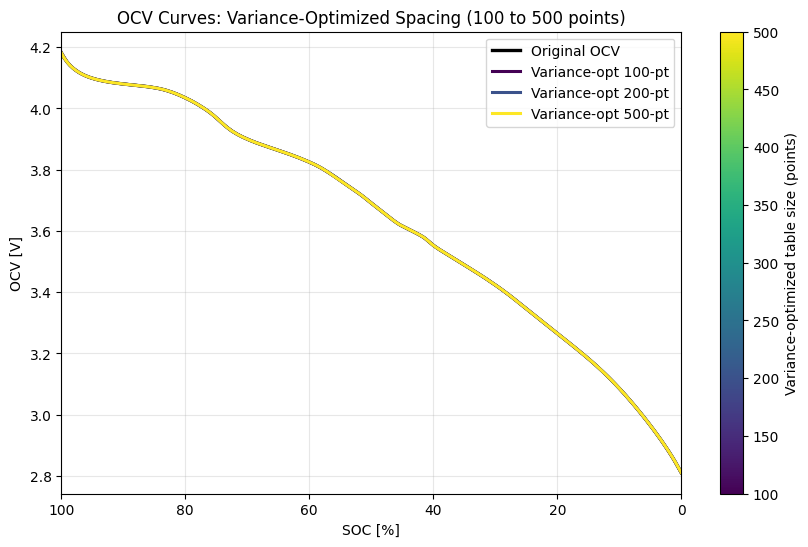

c:\Users\adisa\Documents\Workspace\HVC-Firmware\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


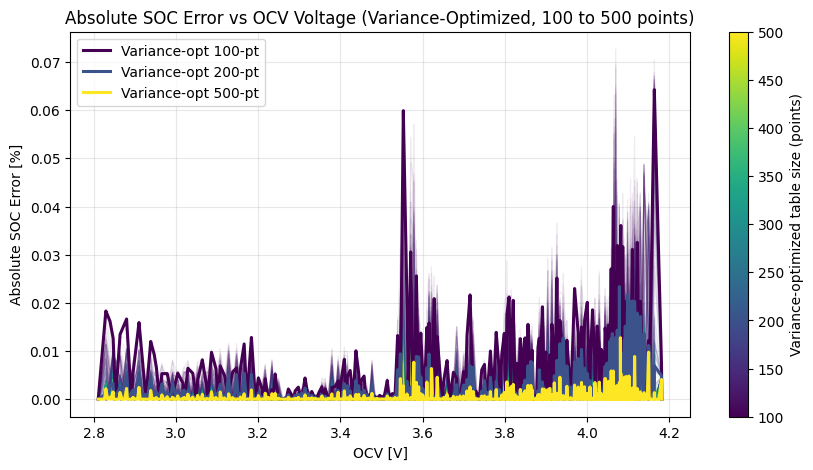

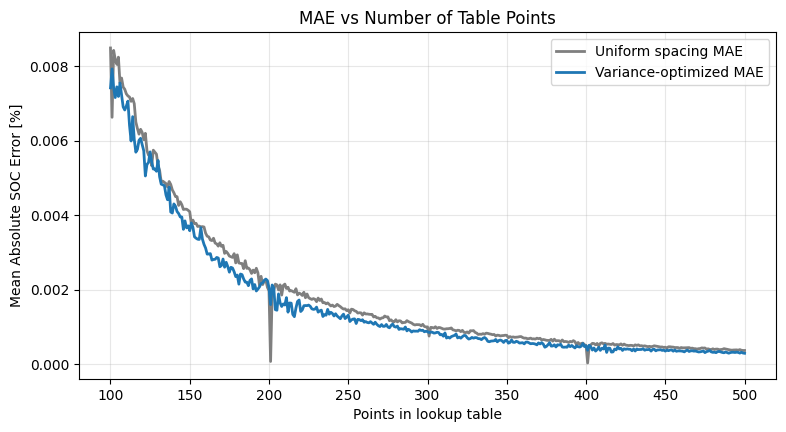

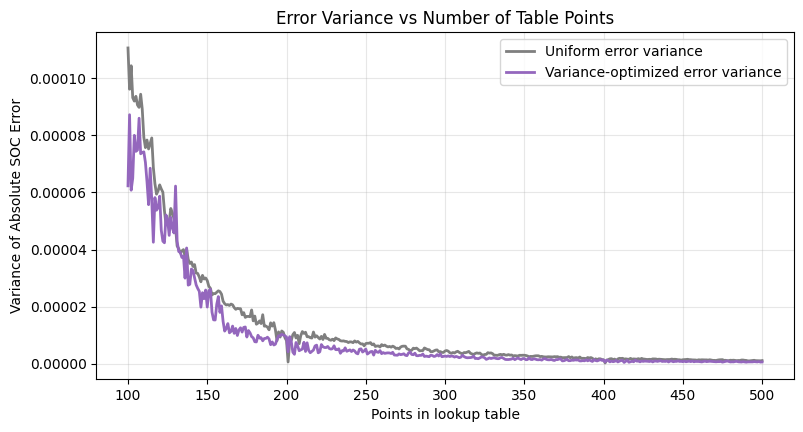

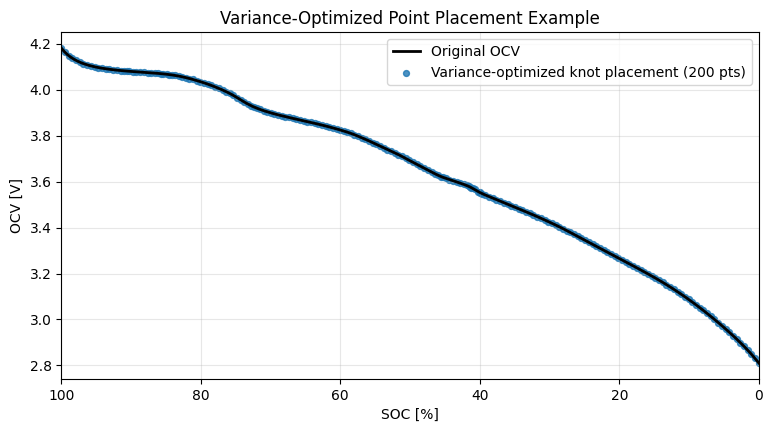

(   points  MAE_uniform_SOC_pct  MAE_variance_SOC_pct  Var_uniform_SOC_pct2  \
 0     100             0.008488              0.007417              0.000111   
 1     101             0.006627              0.007925              0.000096   
 2     102             0.008423              0.007417              0.000104   
 3     103             0.008178              0.007157              0.000093   
 4     104             0.008049              0.007444              0.000092   
 
    Var_variance_SOC_pct2  MaxAbsErr_uniform_SOC_pct  \
 0               0.000062                   0.070327   
 1               0.000087                   0.068543   
 2               0.000061                   0.067765   
 3               0.000065                   0.066988   
 4               0.000080                   0.066213   
 
    MaxAbsErr_variance_SOC_pct  
 0                    0.064259  
 1                    0.069542  
 2                    0.063109  
 3                    0.065133  
 4                   

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors

def estimate_ocv_linear_interp(soc_percent, ocv_lookup_df):
    lookup = (
        ocv_lookup_df[["SOC [%]", "OCV [V]"]]
        .dropna()
        .drop_duplicates(subset="SOC [%]", keep="first")
        .sort_values("SOC [%]")
    )

    soc_bp_local = lookup["SOC [%]"].to_numpy(dtype=float)
    ocv_bp_local = lookup["OCV [V]"].to_numpy(dtype=float)
    soc_query = np.asarray(soc_percent, dtype=float)
    return np.interp(soc_query, soc_bp_local, ocv_bp_local, left=ocv_bp_local[0], right=ocv_bp_local[-1])

def estimate_soc_from_ocv_linear_interp(ocv_volts, ocv_lookup_df):
    lookup = (
        ocv_lookup_df[["OCV [V]", "SOC [%]"]]
        .dropna()
        .drop_duplicates(subset="OCV [V]", keep="first")
        .sort_values("OCV [V]")
    )

    ocv_bp_local = lookup["OCV [V]"].to_numpy(dtype=float)
    soc_bp_local = lookup["SOC [%]"].to_numpy(dtype=float)
    ocv_query = np.asarray(ocv_volts, dtype=float)
    return np.interp(ocv_query, ocv_bp_local, soc_bp_local, left=soc_bp_local[0], right=soc_bp_local[-1])

def build_uniform_estimate_table(point_count, soc_bp, ocv_bp):
    table = pd.DataFrame({
        "SOC [%]": np.linspace(100.0, 0.0, point_count)
    })
    table["OCV [V]"] = np.interp(
        table["SOC [%]"].to_numpy(dtype=float),
        soc_bp,
        ocv_bp,
        left=ocv_bp[0],
        right=ocv_bp[-1]
    )
    return table

def build_variance_optimized_estimate_table(
    point_count,
    soc_ref,
    ocv_ref,
    alpha=8.0,
    gamma=1.4,
    smooth_window=9,
    passes=4,
    tol=1e-5,
 ):
    # Iteratively re-space knots to reduce variance of |SOC_error| over the OCV domain.
    table = build_uniform_estimate_table(point_count, soc_ref, ocv_ref)
    prev_var = np.inf

    for _ in range(passes):
        soc_est = estimate_soc_from_ocv_linear_interp(ocv_ref, table)
        abs_err = np.abs(soc_ref - soc_est)
        err_var = float(np.var(abs_err))

        if (prev_var - err_var) < tol:
            break
        prev_var = err_var

        centered_sq = np.square(abs_err - np.mean(abs_err))

        if smooth_window > 1:
            kernel = np.ones(smooth_window, dtype=float) / float(smooth_window)
            centered_sq = np.convolve(centered_sq, kernel, mode="same")

        max_centered = float(np.max(centered_sq))
        if max_centered <= 1e-12:
            break

        # Higher density where local contribution to variance is larger.
        density = 1.0 + alpha * np.power(centered_sq / max_centered, gamma)

        delta_soc = np.diff(soc_ref)
        avg_density = 0.5 * (density[:-1] + density[1:])
        cumulative = np.concatenate(([0.0], np.cumsum(avg_density * delta_soc)))
        total = float(cumulative[-1])

        target = np.linspace(0.0, total, point_count)
        soc_knots = np.interp(target, cumulative, soc_ref)
        ocv_knots = np.interp(soc_knots, soc_ref, ocv_ref)

        table = pd.DataFrame({
            "SOC [%]": soc_knots[::-1],
            "OCV [V]": ocv_knots[::-1]
        })

    return table

plot_df = (
    rs50_data_ocv[["SOC [%]", "OCV [V]"]]
    .dropna()
    .query("`SOC [%]` >= 0 and `SOC [%]` <= 100")
    .sort_values("SOC [%]")
    .reset_index(drop=True)
)

soc_bp = plot_df["SOC [%]"].to_numpy(dtype=float)
ocv_bp = plot_df["OCV [V]"].to_numpy(dtype=float)

point_counts = list(range(100, 501))
uniform_tables = {n: build_uniform_estimate_table(n, soc_bp, ocv_bp) for n in point_counts}
variance_tables = {n: build_variance_optimized_estimate_table(n, soc_bp, ocv_bp) for n in point_counts}

# Keep compatibility with the comparison cell below.
adaptive_tables = variance_tables

estimate_200_pts_adaptive = variance_tables[200].copy()

norm = colors.Normalize(vmin=min(point_counts), vmax=max(point_counts))
cmap = cm.viridis
highlights = [100, 200, 500]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    plot_df["SOC [%]"],
    plot_df["OCV [V]"],
    label="Original OCV",
    linewidth=2.4,
    color="black"
 )

for n in point_counts:
    ocv_est = estimate_ocv_linear_interp(plot_df["SOC [%]"], variance_tables[n])
    ax.plot(
        plot_df["SOC [%]"],
        ocv_est,
        color=cmap(norm(n)),
        alpha=0.08,
        linewidth=0.8
    )

for n in highlights:
    ocv_est = estimate_ocv_linear_interp(plot_df["SOC [%]"], variance_tables[n])
    ax.plot(
        plot_df["SOC [%]"],
        ocv_est,
        color=cmap(norm(n)),
        linewidth=2.2,
        label=f"Variance-opt {n}-pt"
    )

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Variance-optimized table size (points)")

ax.set_title("OCV Curves: Variance-Optimized Spacing (100 to 500 points)")
ax.set_xlabel("SOC [%]")
ax.set_ylabel("OCV [V]")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(100, 0)
plt.show()

err_df = plot_df.sort_values("OCV [V]").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))

metrics_rows = []
for n in point_counts:
    soc_est_uniform = estimate_soc_from_ocv_linear_interp(err_df["OCV [V]"], uniform_tables[n])
    soc_est_var = estimate_soc_from_ocv_linear_interp(err_df["OCV [V]"], variance_tables[n])

    abs_err_uniform = np.abs(err_df["SOC [%]"].to_numpy(dtype=float) - soc_est_uniform)
    abs_err_var = np.abs(err_df["SOC [%]"].to_numpy(dtype=float) - soc_est_var)

    ax.plot(
        err_df["OCV [V]"],
        abs_err_var,
        color=cmap(norm(n)),
        alpha=0.08,
        linewidth=0.8
    )

    metrics_rows.append({
        "points": n,
        "MAE_uniform_SOC_pct": float(np.mean(abs_err_uniform)),
        "MAE_variance_SOC_pct": float(np.mean(abs_err_var)),
        "Var_uniform_SOC_pct2": float(np.var(abs_err_uniform)),
        "Var_variance_SOC_pct2": float(np.var(abs_err_var)),
        "MaxAbsErr_uniform_SOC_pct": float(np.max(abs_err_uniform)),
        "MaxAbsErr_variance_SOC_pct": float(np.max(abs_err_var))
    })

for n in highlights:
    soc_est_var = estimate_soc_from_ocv_linear_interp(err_df["OCV [V]"], variance_tables[n])
    abs_err_var = np.abs(err_df["SOC [%]"].to_numpy(dtype=float) - soc_est_var)
    ax.plot(
        err_df["OCV [V]"],
        abs_err_var,
        color=cmap(norm(n)),
        linewidth=2.2,
        label=f"Variance-opt {n}-pt"
    )

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Variance-optimized table size (points)")

ax.set_title("Absolute SOC Error vs OCV Voltage (Variance-Optimized, 100 to 500 points)")
ax.set_xlabel("OCV [V]")
ax.set_ylabel("Absolute SOC Error [%]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

metrics_df = pd.DataFrame(metrics_rows).sort_values("points").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    metrics_df["points"],
    metrics_df["MAE_uniform_SOC_pct"],
    label="Uniform spacing MAE",
    color="tab:gray",
    linewidth=2
 )
ax.plot(
    metrics_df["points"],
    metrics_df["MAE_variance_SOC_pct"],
    label="Variance-optimized MAE",
    color="tab:blue",
    linewidth=2
 )
ax.set_title("MAE vs Number of Table Points")
ax.set_xlabel("Points in lookup table")
ax.set_ylabel("Mean Absolute SOC Error [%]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    metrics_df["points"],
    metrics_df["Var_uniform_SOC_pct2"],
    label="Uniform error variance",
    color="tab:gray",
    linewidth=2
 )
ax.plot(
    metrics_df["points"],
    metrics_df["Var_variance_SOC_pct2"],
    label="Variance-optimized error variance",
    color="tab:purple",
    linewidth=2
 )
ax.set_title("Error Variance vs Number of Table Points")
ax.set_xlabel("Points in lookup table")
ax.set_ylabel("Variance of Absolute SOC Error")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

sample_n = 200
sample_tbl = variance_tables[sample_n].sort_values("SOC [%]").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(plot_df["SOC [%]"], plot_df["OCV [V]"], color="black", linewidth=2, label="Original OCV")
ax.scatter(
    sample_tbl["SOC [%]"],
    sample_tbl["OCV [V]"],
    s=18,
    color="tab:blue",
    alpha=0.8,
    label=f"Variance-optimized knot placement ({sample_n} pts)"
 )
ax.set_title("Variance-Optimized Point Placement Example")
ax.set_xlabel("SOC [%]")
ax.set_ylabel("OCV [V]")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(100, 0)
plt.show()

metrics_df.head(), metrics_df.tail()

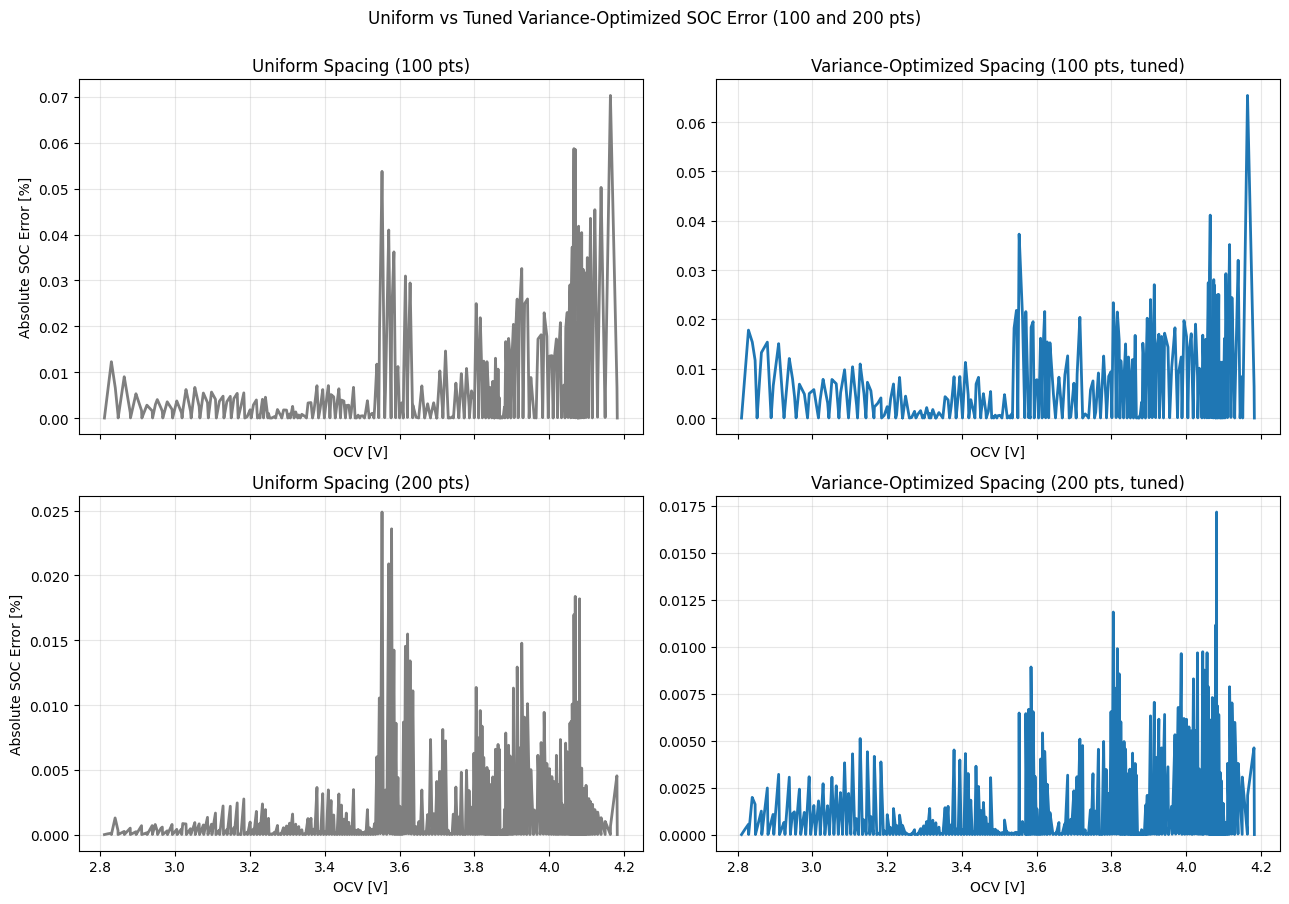

(   alpha  gamma  smooth_window  passes       MAE       VAR       MAX
 0    6.0    1.4             11       2  0.007587  0.000056  0.065401
 1    2.0    1.4              5       2  0.007324  0.000058  0.064430
 2    2.0    1.4              3       2  0.007284  0.000058  0.064414
 3    2.0    1.4              7       2  0.007368  0.000058  0.064437
 4    2.0    1.4              9       2  0.007480  0.000059  0.064442
 5    6.0    1.6             11       2  0.007599  0.000059  0.066559
 6    6.0    1.6              9       2  0.007615  0.000059  0.066811
 7    2.0    1.4             11       2  0.007565  0.000060  0.064443
 8    8.0    1.4              7       2  0.007705  0.000062  0.064078
 9    8.0    1.4              9       2  0.007417  0.000062  0.064259,
    alpha  gamma  smooth_window  passes       MAE       VAR       MAX
 0    4.0    1.4             11       3  0.001492  0.000003  0.017155
 1    2.0    1.4             11       3  0.001557  0.000004  0.016286
 2    4.0    2.0   

In [24]:
target_point_counts = [100, 200]

missing = [n for n in target_point_counts if n not in uniform_tables]
if missing:
    raise ValueError(f"Missing point counts in uniform tables: {missing}")

# Tune variance-optimization settings specifically for selected point counts.
alpha_grid = [2.0, 4.0, 6.0, 8.0, 10.0, 12.0]
gamma_grid = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
smooth_grid = [3, 5, 7, 9, 11]
passes_grid = [2, 3, 4, 5, 6]

soc_true = err_df["SOC [%]"].to_numpy(dtype=float)
ocv_query = err_df["OCV [V]"].to_numpy(dtype=float)

best_by_n = {}
tuning_tables = {}
summary_rows = []

for comparison_n in target_point_counts:
    best = None
    best_table = None
    tuning_rows = []

    for alpha in alpha_grid:
        for gamma in gamma_grid:
            for smooth_window in smooth_grid:
                for passes in passes_grid:
                    cand_table = build_variance_optimized_estimate_table(
                        comparison_n,
                        soc_bp,
                        ocv_bp,
                        alpha=alpha,
                        gamma=gamma,
                        smooth_window=smooth_window,
                        passes=passes,
                        tol=1e-7,
                    )

                    soc_est = estimate_soc_from_ocv_linear_interp(ocv_query, cand_table)
                    abs_err = np.abs(soc_true - soc_est)
                    mae = float(np.mean(abs_err))
                    err_var = float(np.var(abs_err))
                    max_err = float(np.max(abs_err))

                    row = {
                        "alpha": alpha,
                        "gamma": gamma,
                        "smooth_window": smooth_window,
                        "passes": passes,
                        "MAE": mae,
                        "VAR": err_var,
                        "MAX": max_err,
                    }
                    tuning_rows.append(row)

                    if (best is None) or (err_var < best["VAR"]) or (
                        np.isclose(err_var, best["VAR"]) and mae < best["MAE"]
                    ):
                        best = row
                        best_table = cand_table

    # Keep best-tuned table accessible for downstream use/export.
    if comparison_n == 100:
        estimate_100_pts_variance_optimized = best_table.copy()
    if comparison_n == 200:
        estimate_200_pts_variance_optimized = best_table.copy()

    adaptive_tables[comparison_n] = best_table.copy()
    best_by_n[comparison_n] = {"params": best, "table": best_table}

    tuning_df_n = pd.DataFrame(tuning_rows).sort_values(["VAR", "MAE"]).reset_index(drop=True)
    tuning_tables[comparison_n] = tuning_df_n

    # Baseline uniform metrics.
    uniform_table = uniform_tables[comparison_n]
    soc_est_uniform = estimate_soc_from_ocv_linear_interp(ocv_query, uniform_table)
    abs_err_uniform = np.abs(soc_true - soc_est_uniform)

    # Best-tuned variance metrics.
    soc_est_opt = estimate_soc_from_ocv_linear_interp(ocv_query, best_table)
    abs_err_opt = np.abs(soc_true - soc_est_opt)

    summary_rows.append({
        "points": comparison_n,
        "alpha": best["alpha"],
        "gamma": best["gamma"],
        "smooth_window": best["smooth_window"],
        "passes": best["passes"],
        "Uniform_MAE_pct": float(np.mean(abs_err_uniform)),
        "Tuned_MAE_pct": float(np.mean(abs_err_opt)),
        "Uniform_VAR": float(np.var(abs_err_uniform)),
        "Tuned_VAR": float(np.var(abs_err_opt)),
        "Uniform_MAX_pct": float(np.max(abs_err_uniform)),
        "Tuned_MAX_pct": float(np.max(abs_err_opt)),
    })

# Plot side-by-side for each point-count (row = point-count, col = uniform/tuned).
fig, axes = plt.subplots(len(target_point_counts), 2, figsize=(13, 4.5 * len(target_point_counts)), sharex=True)
if len(target_point_counts) == 1:
    axes = np.array([axes])

for row_idx, comparison_n in enumerate(target_point_counts):
    uniform_table = uniform_tables[comparison_n]
    tuned_table = best_by_n[comparison_n]["table"]

    soc_est_uniform = estimate_soc_from_ocv_linear_interp(ocv_query, uniform_table)
    soc_est_tuned = estimate_soc_from_ocv_linear_interp(ocv_query, tuned_table)

    abs_err_uniform = np.abs(soc_true - soc_est_uniform)
    abs_err_tuned = np.abs(soc_true - soc_est_tuned)

    ax_l = axes[row_idx, 0]
    ax_r = axes[row_idx, 1]

    ax_l.plot(err_df["OCV [V]"], abs_err_uniform, color="tab:gray", linewidth=2)
    ax_l.set_title(f"Uniform Spacing ({comparison_n} pts)")
    ax_l.set_xlabel("OCV [V]")
    ax_l.set_ylabel("Absolute SOC Error [%]")
    ax_l.grid(True, alpha=0.3)

    ax_r.plot(err_df["OCV [V]"], abs_err_tuned, color="tab:blue", linewidth=2)
    ax_r.set_title(f"Variance-Optimized Spacing ({comparison_n} pts, tuned)")
    ax_r.set_xlabel("OCV [V]")
    ax_r.grid(True, alpha=0.3)

fig.suptitle("Uniform vs Tuned Variance-Optimized SOC Error (100 and 200 pts)", y=1.0)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(summary_rows).sort_values("points").reset_index(drop=True)
summary_df

tuning_tables[100].head(10), tuning_tables[200].head(10)

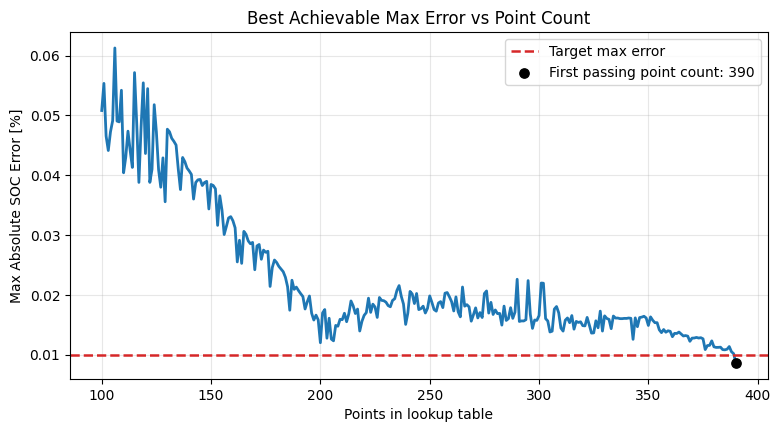

Smallest point count meeting threshold:
points=390
alpha=2.0, gamma=1.6, smooth_window=11, passes=2
max error=0.008627%
mae=0.000445%


,points,best_max_err_pct,best_mae_pct,alpha,gamma,smooth_window,passes
281,381,0.011228,0.000615,2.0,1.2,11,2
282,382,0.011236,0.000571,4.0,1.2,11,2
283,383,0.011265,0.000566,10.0,1.4,11,2
284,384,0.010858,0.000466,6.0,1.2,9,2
285,385,0.010825,0.000500,8.0,1.6,7,2
286,386,0.010925,0.000481,8.0,1.4,7,2
287,387,0.011371,0.000527,10.0,1.2,7,2
288,388,0.010513,0.000590,2.0,1.4,7,2
289,389,0.010179,0.000561,6.0,1.6,11,2
290,390,0.008627,0.000445,2.0,1.6,11,2


In [ ]:
# CAREFUL, THIS TAKES 22 MIN to RUN

target_max_error_pct = 0.01
point_min = 100
point_max = 500

# Focused hyperparameter grid around strong settings from prior tuning.
alpha_grid = [2.0, 4.0, 6.0, 8.0, 10.0]
gamma_grid = [1.2, 1.4, 1.6, 2.0]
smooth_grid = [7, 9, 11]
passes_grid = [2, 3, 4]

soc_true = err_df["SOC [%]"].to_numpy(dtype=float)
ocv_query = err_df["OCV [V]"].to_numpy(dtype=float)

search_rows = []
smallest_solution = None

for n in range(point_min, point_max + 1):
    best_for_n = None

    for alpha in alpha_grid:
        for gamma in gamma_grid:
            for smooth_window in smooth_grid:
                for passes in passes_grid:
                    cand_table = build_variance_optimized_estimate_table(
                        n,
                        soc_bp,
                        ocv_bp,
                        alpha=alpha,
                        gamma=gamma,
                        smooth_window=smooth_window,
                        passes=passes,
                        tol=1e-7,
                    )

                    soc_est = estimate_soc_from_ocv_linear_interp(ocv_query, cand_table)
                    abs_err = np.abs(soc_true - soc_est)
                    max_err = float(np.max(abs_err))
                    mae_err = float(np.mean(abs_err))

                    if (best_for_n is None) or (max_err < best_for_n["max_err"]) or (
                        np.isclose(max_err, best_for_n["max_err"]) and mae_err < best_for_n["mae_err"]
                    ):
                        best_for_n = {
                            "points": n,
                            "alpha": alpha,
                            "gamma": gamma,
                            "smooth_window": smooth_window,
                            "passes": passes,
                            "max_err": max_err,
                            "mae_err": mae_err,
                            "table": cand_table,
                        }

    search_rows.append({
        "points": best_for_n["points"],
        "best_max_err_pct": best_for_n["max_err"],
        "best_mae_pct": best_for_n["mae_err"],
        "alpha": best_for_n["alpha"],
        "gamma": best_for_n["gamma"],
        "smooth_window": best_for_n["smooth_window"],
        "passes": best_for_n["passes"],
    })

    if (smallest_solution is None) and (best_for_n["max_err"] <= target_max_error_pct):
        smallest_solution = best_for_n
        estimate_min_pts_variance_optimized = best_for_n["table"].copy()
        break

search_df = pd.DataFrame(search_rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(search_df["points"], search_df["best_max_err_pct"], color="tab:blue", linewidth=2)
ax.axhline(target_max_error_pct, color="tab:red", linestyle="--", linewidth=1.8, label="Target max error")
if smallest_solution is not None:
    ax.scatter(
        [smallest_solution["points"]],
        [smallest_solution["max_err"]],
        color="black",
        s=45,
        zorder=5,
        label=f"First passing point count: {smallest_solution['points']}"
    )
ax.set_title("Best Achievable Max Error vs Point Count")
ax.set_xlabel("Points in lookup table")
ax.set_ylabel("Max Absolute SOC Error [%]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

if smallest_solution is None:
    print(f"No solution found in [{point_min}, {point_max}] with max error <= {target_max_error_pct:.4f}%")
else:
    print("Smallest point count meeting threshold:")
    print(f"points={smallest_solution['points']}")
    print(
        f"alpha={smallest_solution['alpha']}, gamma={smallest_solution['gamma']}, "
        f"smooth_window={smallest_solution['smooth_window']}, passes={smallest_solution['passes']}"
    )
    print(f"max error={smallest_solution['max_err']:.6f}%")
    print(f"mae={smallest_solution['mae_err']:.6f}%")

search_df.tail(10)

In [26]:
from generate_ocv_table import write_ocv_header

FILE_NAME = "../Core/Src/Config/ocv_lookup_table.c"

write_ocv_header(estimate_min_pts_variance_optimized, FILE_NAME)

In [ ]:
ax = rs50_data_ocv.plot(x="SOC [%]", y = "Voltage [V]")
